In [1]:
import pandas as pd

df = pd.read_parquet('../data/Processed Positions Data.parquet')

In [2]:
important_features = ['numMinutes_player', 'assists_player', 'blocks_player', 'steals_player',
       'fieldGoalsMade_player', 'threePointersMade_player',
       'threePointersPercentage_player', 'freeThrowsAttempted_player',
       'freeThrowsPercentage_player', 'reboundsDefensive_player',
       'reboundsOffensive_player', 'reboundsTotal_player', 'turnovers_player',
       'plusMinusPoints_player', 'threePointersAttempted_per36',
       'foulsPersonal_per36', 'foulsPersonalPercent',
       'fgRelativePercent', 'FTA_rate', 'USG']
df['foulsPersonalPercent'] = df['foulsPersonalPercent'].fillna(df['foulsPersonalPercent'].median())

C:\Users\vtapi\AppData\Local\Temp\ipykernel_27656\1949144276.py:26: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(position_gap)


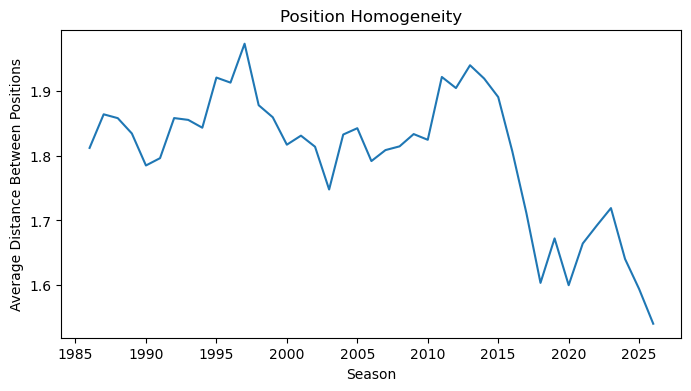

<Figure size 640x480 with 0 Axes>

In [3]:
from sklearn.preprocessing import StandardScaler
import numpy as np
from scipy.spatial.distance import pdist
import matplotlib.pyplot as plt

df[important_features] = StandardScaler().fit_transform(df[important_features])

def position_gap(season_df):
    # mean feature vector for each position in that season
    grouped = (
        season_df
        .groupby("Position")[important_features]
        .mean()
    )

    # need at least 2 positions to compare
    if len(grouped) < 2:
        return np.nan

    # average pairwise euclidean distance between position centroids
    return pdist(grouped.values, metric="euclidean").mean()

gap_by_season = (
    df
    .groupby("season")
    .apply(position_gap)
    .reset_index(name="position_gap")
)

gap_by_season = gap_by_season.sort_values('season').iloc[2:]

plt.figure(figsize=(8, 4))
plt.plot(
    gap_by_season["season"],
    gap_by_season["position_gap"],
)

plt.title("Position Homogeneity")
plt.xlabel("Season")
plt.ylabel("Average Distance Between Positions")
plt.show()

plt.savefig('../output/Position Homogeneity Over Time.svg')

In [4]:
%pip install ruptures

Note: you may need to restart the kernel to use updated packages.


In [5]:
import ruptures as rpt

signal = np.array(gap_by_season['position_gap']).reshape(-1, 1)

model = rpt.Pelt(model="rbf").fit(signal)
bkps = model.predict(pen=5)   # main tuning knob

change_points = bkps[:-1]
change_years = gap_by_season['season'][change_points]

print(change_years)

for pen in [3, 4, 5, 6, 7, 8, 12]:
    model = rpt.Pelt(model="rbf").fit(signal)
    bkps = model.predict(pen=pen)
    print(pen, gap_by_season['season'][bkps[:-1]])


30    2014
Name: season, dtype: int32
3 30    2014
Name: season, dtype: int32
4 30    2014
Name: season, dtype: int32
5 30    2014
Name: season, dtype: int32
6 30    2014
Name: season, dtype: int32
7 30    2014
Name: season, dtype: int32
8 Series([], Name: season, dtype: int32)
12 Series([], Name: season, dtype: int32)


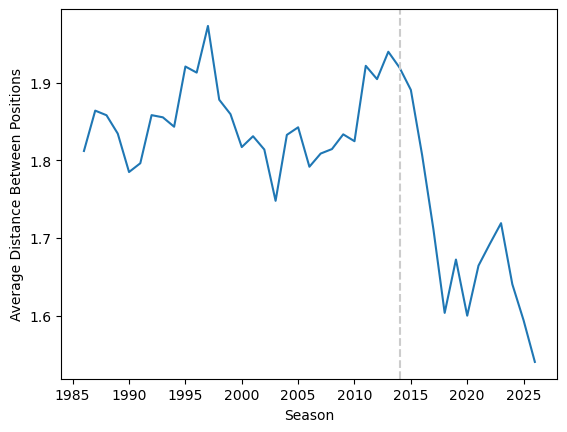

In [6]:
plt.plot(
    gap_by_season["season"],
    gap_by_season["position_gap"],
)
plt.xlabel("Season")
plt.ylabel("Average Distance Between Positions")
plt.axvline(change_years.iloc[0], linestyle='--', color='#cccccc')

fig = plt.gcf()

fig.savefig('../output/Figures/Position Homogeneity Over Time.svg')

In [7]:
gap_by_season

,season,position_gap
2,1986,1.812101
3,1987,1.864053
4,1988,1.858124
5,1989,1.834452
6,1990,1.784994
7,1991,1.796312
8,1992,1.858242
9,1993,1.855438
10,1994,1.843324
11,1995,1.920831
